## Homework 8: QDA

##### Загальні імпорти

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from numpy.linalg import inv, det

sns.set_style("darkgrid")

### 1. Завантаження даних та 2. Розподіл на вибірки

In [42]:
iris = load_iris()

# Створення DataFrame:
# - data: містить ознаки (sepal length, sepal width, petal length, petal width)
# - target: містить числові мітки класів (0, 1, 2)
# - target_names: містить назви класів ('setosa', 'versicolor', 'virginica')

iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names
print(f"Ознаки: {X.shape[1]}, Класи: {len(np.unique(y))}\n")
print("Назви ознак:", feature_names)
print("Назви класів:", target_names, "\n")

# --- Крок 2: Розподіл на вибірки ---

# Розділяємо дані на тренувальні та тестові (80% train, 20% test)
# Використовуємо stratify для збереження балансу класів
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(f"Розмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")


Ознаки: 4, Класи: 3

Назви ознак: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Назви класів: ['setosa' 'versicolor' 'virginica'] 

Розмір навчальної вибірки: (120, 4)
Розмір тестової вибірки: (30, 4)


### 3, 4, 5, 6. Розрахунок матриць коваріації, обернених матриць та апріорних імовірностей

In [43]:
classes = np.unique(y_train)

# Списки для зберігання параметрів
X_class_list = []   # Вибірки ознак для кожного класу
X_cov_list = []     # Матриці коваріації для кожного класу
X_inv_cov_list = [] # Обернені матриці коваріації для кожного класу
X_prob_list = []    # Апріорні імовірності для кожного класу

for k in classes:
    # 3. Вибірка ознак окремо для кожного класу
    X_k = X_train[y_train == k]
    X_class_list.append(X_k)
    
    # 6. Обчислення апріорної імовірності
    P_k = len(X_k) / len(X_train)
    X_prob_list.append(P_k)
    
    # 4. Розрахунок матриці коваріації
    cov_k = np.cov(X_k.T)
    X_cov_list.append(cov_k)
    
    # 5. Розрахунок оберненої матриці коваріації
    inv_cov_k = inv(cov_k)
    X_inv_cov_list.append(inv_cov_k)

print(f"Апріорні імовірності (X_prob_list): {X_prob_list}\n")

verbose = True  # Змінити на False, щоб вимкнути детальний вивід
if verbose:
    print("--- Матриці коваріації для кожного класу (X_cov_list): ---")
    for i, cov in enumerate(X_cov_list):
        print(f"Клас {i}:\n{cov}\n")
    print("--- Обернені матриці коваріації для кожного класу (X_inv_cov_list): ---")
    for i, inv_cov in enumerate(X_inv_cov_list):
        print(f"Клас {i}:\n{inv_cov}\n")
    print("--- Вибірки ознак для кожного класу (X_class_list): ---")
    for i, X_class in enumerate(X_class_list):
        print(f"Клас {i}:\n{X_class}\n")


Апріорні імовірності (X_prob_list): [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]

--- Матриці коваріації для кожного класу (X_cov_list): ---
Клас 0:
[[0.09515385 0.09535897 0.00965385 0.01238462]
 [0.09535897 0.15925641 0.01547436 0.01146154]
 [0.00965385 0.01547436 0.02589103 0.00614103]
 [0.01238462 0.01146154 0.00614103 0.01330769]]

Клас 1:
[[0.22728205 0.06538462 0.14992308 0.04092308]
 [0.06538462 0.09538462 0.06269231 0.03358974]
 [0.14992308 0.06269231 0.19640385 0.06046154]
 [0.04092308 0.03358974 0.06046154 0.03497436]]

Клас 2:
[[0.46912821 0.11302564 0.35123077 0.04882051]
 [0.11302564 0.12523077 0.09394872 0.05235897]
 [0.35123077 0.09394872 0.33189744 0.05876923]
 [0.04882051 0.05235897 0.05876923 0.07220513]]

--- Обернені матриці коваріації для кожного класу (X_inv_cov_list): ---
Клас 0:
[[ 28.19923241 -16.1451288    2.31475455 -13.40605086]
 [-16.1451288   16.14569153  -4.3741705    3.13793243]
 [  2.31475455  -4.3741705   44.9072963  -19.10996088]
 [-1

### 7. Функція обчислення значень дискримінантної функції (для 1 рядка)

In [44]:

def g(x_test, X_class, X_cov, X_inv_cov, X_prob):
    """
    Розрахунок дискримінантної функції для одного зразка x_test і одного класу.
    """
    cov_det = np.linalg.det(X_cov)
    log_cov_det = np.log(cov_det)
    x_mean = np.reshape(np.mean(X_class, axis=0), (np.shape(X_class)[1], 1))
    diff = x_test.reshape(-1, 1) - x_mean
    g_i = -0.5 * diff.T @ X_inv_cov @ diff - 0.5 * log_cov_det + np.log(X_prob)
    return g_i.flatten()[0]

In [45]:
random_index = np.random.randint(0, X_test.shape[0])
print(f"Тестування функції g() для випадкового зразка X_test[{random_index}]:")
print("Зразок", X_test[random_index], "->", "target class:", y_test[random_index])
for k in classes:
    score = g(X_test[random_index], X_class_list[k], X_cov_list[k], X_inv_cov_list[k], X_prob_list[k])
    print(f"  Клас {k}: {score.flatten()[0]:.4f}")

Тестування функції g() для випадкового зразка X_test[4]:
Зразок [4.4 3.2 1.3 0.2] -> target class: 0
  Клас 0: 2.0719
  Клас 1: -39.0819
  Клас 2: -73.9330


### 8. Функція обчислення для всієї матриці та прогноз

In [46]:
# --- Покращена функція (без хардкоду) ---
def g_matrix(X_test, X_class_list, X_cov_list, X_inv_cov_list, X_prob_list):
    """
    Розрахунок дискримінантних функцій та імовірностей для всієї тестової вибірки.
    """
    n_classes = len(X_class_list) # Динамічно визначаємо кількість класів
    g_val = []   # Список для зберігання значень g(x) для всіх зразків
    g_proba = [] # Список для зберігання ймовірностей для всіх зразків

    for i in range(len(X_test)):
        x_test = X_test[i]

        # Список для зберігання значень g(x) для кожного класу
        g_i_scores = []

        for k in range(n_classes):
            # Викликаємо функцію g для класу k
            score = g(
                x_test, 
                X_class_list[k], 
                X_cov_list[k], 
                X_inv_cov_list[k], 
                X_prob_list[k]
            )
            g_i_scores.append(score)

        g_i_array = np.array(g_i_scores)
        likelihood = np.exp(g_i_array - np.max(g_i_array))
        res = likelihood / np.sum(likelihood)

        g_val.append(g_i_array)
        g_proba.append(res)

    return np.array(g_val), np.array(g_proba)

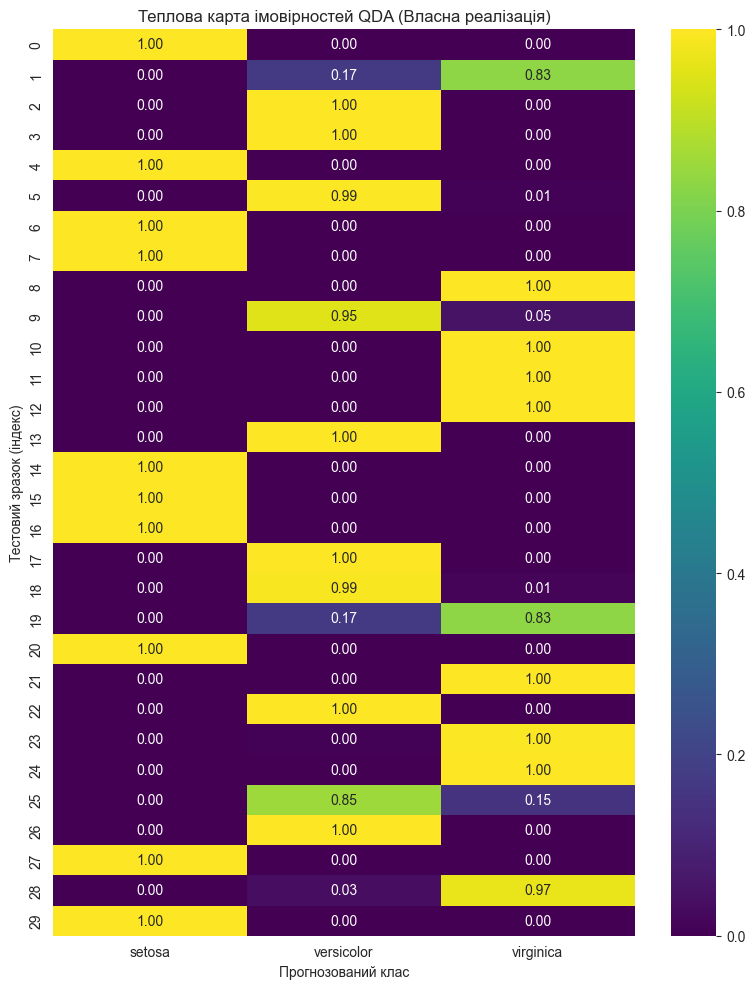

In [47]:
# Отримуємо прогнози для тестової вибірки
g_val_own, g_proba_own = g_matrix(
    X_test,
    X_class_list,
    X_cov_list,
    X_inv_cov_list,
    X_prob_list
)

plt.figure(figsize=(8, 10))
sns.heatmap(
    g_proba_own, 
    annot=True, 
    fmt=".2f", 
    cmap="viridis", 
    xticklabels=target_names
)
plt.title("Теплова карта імовірностей QDA (Власна реалізація)")
plt.xlabel("Прогнозований клас")
plt.ylabel("Тестовий зразок (індекс)")
plt.tight_layout()

### 9. Прогнозування за допомогою sklearn.QDA

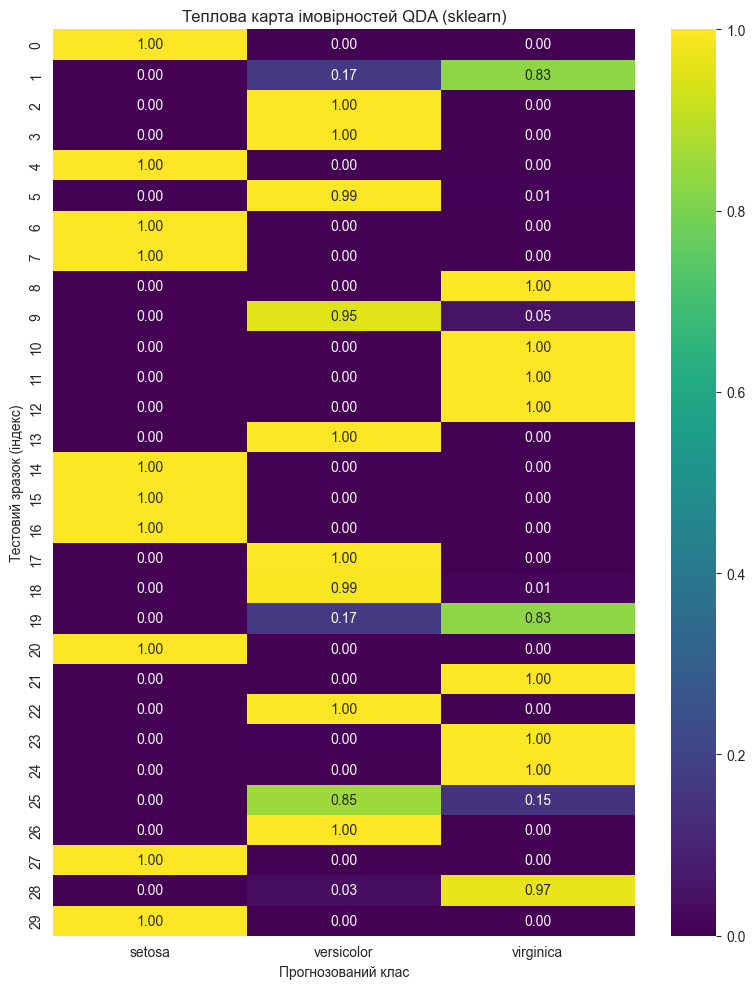

In [48]:
# Ініціалізуємо модель QDA з sklearn
# qda_sklearn = QuadraticDiscriminantAnalysis(priors=X_prob_list)
qda_sklearn = QuadraticDiscriminantAnalysis()
qda_sklearn.fit(X_train, y_train)
proba_sklearn = qda_sklearn.predict_proba(X_test)
values_sklearn = qda_sklearn.decision_function(X_test) 

plt.figure(figsize=(8, 10))
sns.heatmap(
    proba_sklearn, 
    annot=True, 
    fmt=".2f", 
    cmap="viridis", 
    xticklabels=target_names
)
plt.title("Теплова карта імовірностей QDA (sklearn)")
plt.xlabel("Прогнозований клас")
plt.ylabel("Тестовий зразок (індекс)")
plt.tight_layout()

### 10. Порівняння результатів та висновок

--- Порівняння результатів ---
|    |    g0_own |   g1_own |   g2_own |   g0_sklearn |   g1_sklearn |   g2_sklearn |   P0_own |   P1_own |   P2_own |   P0_sklearn |   P1_sklearn |   P2_sklearn |   y_test |   y_pred_own |   y_pred_sklearn |
|---:|----------:|---------:|---------:|-------------:|-------------:|-------------:|---------:|---------:|---------:|-------------:|-------------:|-------------:|---------:|-------------:|-----------------:|
|  0 |    3.0645 | -34.4789 | -69.8699 |       3.0645 |     -34.4789 |     -69.8699 |   1.0000 |   0.0000 |   0.0000 |       1.0000 |       0.0000 |       0.0000 |   0.0000 |       0.0000 |           0.0000 |
|  1 | -284.5863 |   0.3613 |   1.9466 |    -284.5863 |       0.3613 |       1.9466 |   0.0000 |   0.1700 |   0.8300 |       0.0000 |       0.1700 |       0.8300 |   2.0000 |       2.0000 |           2.0000 |
|  2 |  -82.2995 |   1.5081 | -10.1028 |     -82.2995 |       1.5081 |     -10.1028 |   0.0000 |   1.0000 |   0.0000 |       0.0000 |

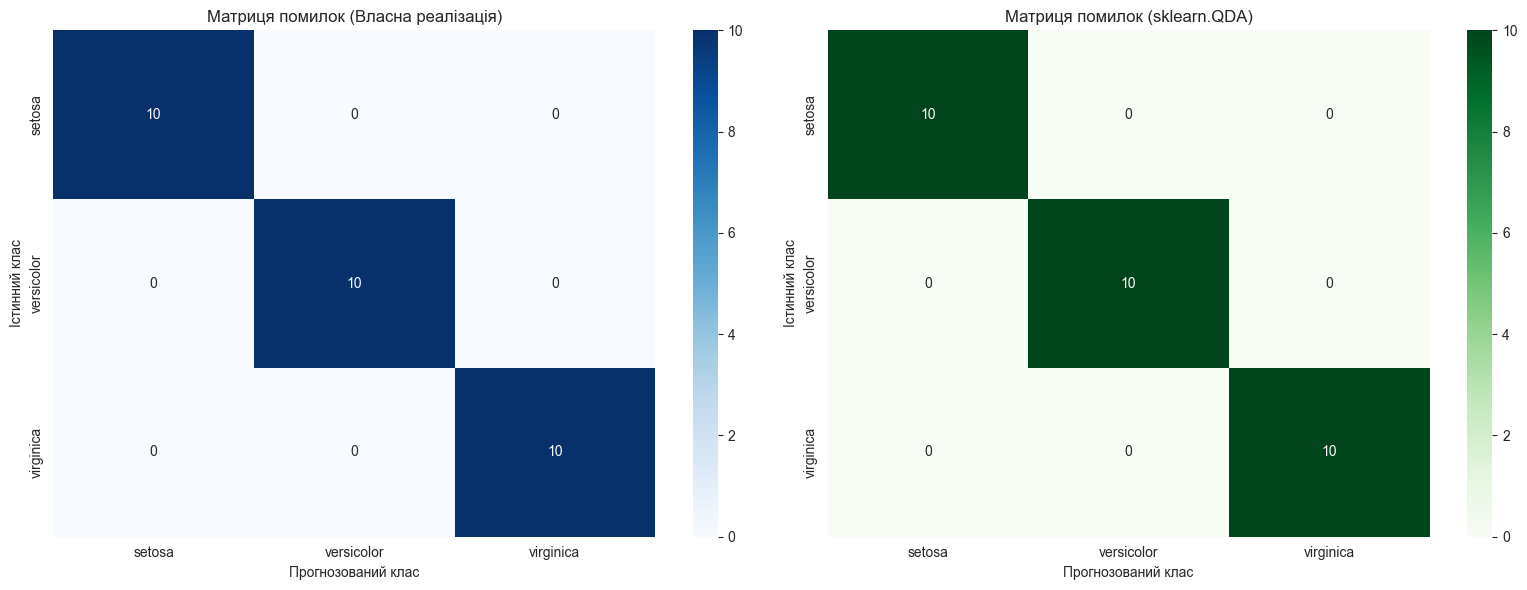

In [49]:
print("--- Порівняння результатів ---")

dataframe = pd.DataFrame({
    "g0_own": g_val_own[:,0], "g1_own": g_val_own[:,1], "g2_own": g_val_own[:,2],
    "g0_sklearn": values_sklearn[:,0], "g1_sklearn": values_sklearn[:,1], "g2_sklearn": values_sklearn[:,2],
    "P0_own": g_proba_own[:,0], "P1_own": g_proba_own[:,1], "P2_own": g_proba_own[:,2],
    "P0_sklearn": proba_sklearn[:,0], "P1_sklearn": proba_sklearn[:,1], "P2_sklearn": proba_sklearn[:,2],
    "y_test": y_test,
    "y_pred_own": y_pred_own,
    "y_pred_sklearn": y_pred_sklearn
})

print(dataframe.head().to_markdown(floatfmt=".4f"))

# Перевірка на повний збіг імовірностей та прогнозів
# Використовуємо np.allclose для порівняння чисел з плаваючою комою
probs_match = np.allclose(g_proba_own, proba_sklearn)
preds_match = np.array_equal(y_pred_own, y_pred_sklearn)

print(f"\nІмовірності (P_own vs P_sklearn) збігаються: {probs_match}")
print(f"Прогнози (y_pred_own vs y_pred_sklearn) збігаються: {preds_match}")

# Візуалізація Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CM для власної реалізації
cm_own = confusion_matrix(y_test, y_pred_own)
sns.heatmap(cm_own, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title('Матриця помилок (Власна реалізація)')
axes[0].set_xlabel('Прогнозований клас')
axes[0].set_ylabel('Істинний клас')

# CM для sklearn
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('Матриця помилок (sklearn.QDA)')
axes[1].set_xlabel('Прогнозований клас')
axes[1].set_ylabel('Істинний клас')

plt.tight_layout()

### Висновки

Власна реалізація QDA, базована на функціях g() та g_matrix(), дає абсолютно ідентичні результати у порівнянні з бібліотечною реалізацією sklearn.QDA.

Імовірності класів (P_own vs P_sklearn) повністю збігаються. Кінцеві прогнози класів (y_pred_own vs y_pred_sklearn) також повністю збігаються.

Матриці помилок ідентичні: обидві моделі не припустились помилок на 30 тестових зразках.